# Inicialização

In [1]:
# Carregando as bibliotecas

import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats as st

In [2]:
# Função que faz um resumo geral do DataFrame

def summary (data):
    consult = pd.DataFrame({
        'type': data.dtypes,            #Tipo de cada coluna
        'missing': data.isna().sum(),   #Quantidade de valores nulos em cada coluna
        'size': data.shape[0],          #Quantidade de linhas
        'unique':data.nunique()         #Qantidade de valores unicos
    })
    return consult

# Carregando os dados

In [3]:
df = pd.read_csv('/datasets/games.csv')

# Preparando o DataFrame

In [4]:
# Colocando todos os nomes das colunas em minúsculo

df.columns = df.columns.str.lower()

In [5]:
# Alterando o tipo da coluna year_of_release

df['year_of_release'] = pd.to_numeric(df['year_of_release'], errors='coerce')

In [6]:
# Corrigindo ausentes na coluna genre

df['genre'] = df['genre'].fillna('ausente')

In [7]:
# Corrigindo ausentes na coluna name

df['name'] = df['name'].fillna('ausente')

In [8]:
# Corrigindo os valores nulos da coluna rating

df['rating'] = df['rating'].fillna('unknown')

In [9]:
# Substituir 'tbd' por NaN

df['user_score'] = df['user_score'].replace('tbd', pd.NA)

In [10]:
# Converter para numérico (valores inválidos viram NaN)

df['user_score'] = pd.to_numeric(df['user_score'], errors='coerce')

In [11]:
# Alterar a escala de avaliação

df['critic_score'] = df['critic_score']/10

In [12]:
# Preenchendo os valores nulos com a media da coluna correspondente

#df['user_score'] = df['user_score'].fillna(df['user_score'].mean())
#df['critic_score'] = df['critic_score'].fillna(df['critic_score'].mean())

# Resumo

* Alguns nomes colunas tinham letra maiúscula, portanto, foram transformados todos em minúsucula.

* A coluna 'year_of_release' foi tratada alterando seu tipo para 'int', pois se trata de um número inteiro.

* A coluna 'user_score' possuia alguns valores 'tbd', os mesmos foram alterados para NaN. Como os usuários ainda não avaliaram o jogo, foi determinado que os valores ficariam como NaN até serem atualizados.

* Converti o type da coluna 'user_score' para float.

* Foi alterada a escala de avaliação da coluna 'critic_score', para que siga o mesmo padrão da coluna 'user_score'.

## Valores ausentes

Foram identificados alguns valores ausentes ao longo do DF.
* Com relação a coluna 'year_of_release'
  - Alguns jogos têm a data em seu nome
  - Jogos muito antigos
  - Problemas na coleta de dados
* Com relação a coluna 'user_score'
  - Jogos com poucos usuários avaliando
  - Sistemas antigos não tinham a opção do usuário avaliar o jogo
* Com relação a coluna 'critic_score'
  - Jogo não foi revisado por críticos profissionais

In [13]:
# Criando uma coluna com a venda total de todas as regiões de cada jogo

df['total_sale'] = df['na_sales'] + df['eu_sales'] + df['jp_sales'] + df['other_sales']

In [14]:
# Criando uma coluna com a media das avaliações

df['media_score'] = df[['critic_score', 'user_score']].mean(axis=1)

In [15]:
# Criando uma coluna que mostra qual a região que mais vendeu o jogo

df['best_region'] = df[['na_sales','eu_sales','jp_sales', 'other_sales']].idxmax(axis=1)

# Analisando os Dados

## Análise de lançamento de jogos por ano

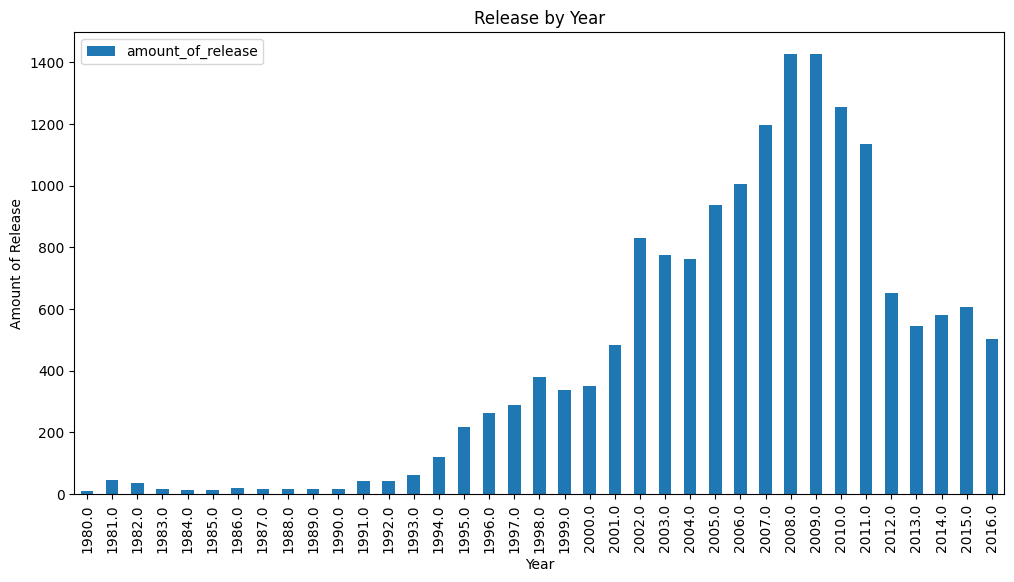

In [16]:
# Verificando a quantidade de jogos vendidos por ano

df_filter_by_year = df.groupby(by='year_of_release').count().reset_index()
df_filter_by_year = df_filter_by_year.rename(columns={'name':'amount_of_release'}).drop(columns=['platform','genre','na_sales', 'eu_sales','jp_sales','other_sales','critic_score','user_score','rating','total_sale', 'media_score','best_region'], axis=1)

# Gerando gráfico
df_filter_by_year.plot(x = 'year_of_release',
                      y = 'amount_of_release',
                      xlabel = 'Year',
                      ylabel = 'Amount of Release',
                      figsize = [12,6],
                      kind = 'bar',
                      title = 'Release by Year')
plt.show()

* Observa-se uma grande quantidade de jogos que não possuem seu ano de lançamento, que são repsentados no eixo 'x' por 0.
* Os lançamentos de jogos aumentaram muito entre os anos 2002 e 2011.

## Análise por plataforma

### Plataformas que mais vendem por ano

In [17]:
# Verificar se há algum duplicado implícito

df['platform'].unique()

array(['Wii', 'NES', 'GB', 'DS', 'X360', 'PS3', 'PS2', 'SNES', 'GBA',
       'PS4', '3DS', 'N64', 'PS', 'XB', 'PC', '2600', 'PSP', 'XOne',
       'WiiU', 'GC', 'GEN', 'DC', 'PSV', 'SAT', 'SCD', 'WS', 'NG', 'TG16',
       '3DO', 'GG', 'PCFX'], dtype=object)

In [18]:
# Agrupando o df pelas plataformas e somando suas vendas

df_filter_by_platform = df.groupby(by='platform').sum().reset_index()
df_filter_by_platform = df_filter_by_platform.drop(columns=['year_of_release','na_sales','eu_sales','jp_sales','other_sales','critic_score','user_score','media_score'], axis=1)
df_filter_by_platform = df_filter_by_platform.sort_values(by='total_sale', ascending=False)

In [19]:
# Criar uma lista das 6 plataformas que mais vendem

top_6_platform = df_filter_by_platform['platform'].head(6).tolist()

In [20]:
# Criando um novo DataFrame agrupando por ano as 6 plataformas mais relevantes

df_filter_by_platform_year = df.groupby(by=['platform','year_of_release']).sum().reset_index().sort_values(by=['platform','year_of_release'])
df_filter_by_platform_year = df_filter_by_platform_year.drop(columns=['na_sales','eu_sales','jp_sales','other_sales','critic_score','user_score','media_score'])
df_filter_by_top6_platform_year = df_filter_by_platform_year[df_filter_by_platform_year['platform'].isin(top_6_platform)]

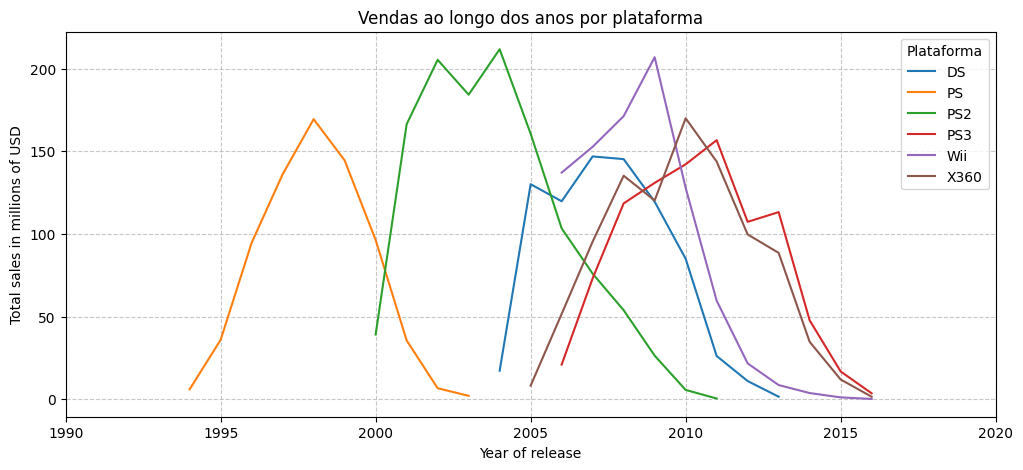

In [21]:
# Gera um pivot para organizar os dados
pivot_df = df_filter_by_top6_platform_year.pivot_table(
    index='year_of_release',
    columns='platform',
    values='total_sale',
    aggfunc='sum'
)
plt.figure(figsize=(12,5))

# Faz o plot de todas as plataformas automaticamente
for plataforma in pivot_df.columns:
    plt.plot(pivot_df.index, pivot_df[plataforma], label=plataforma)

plt.xlabel("Year of release")
plt.ylabel("Total sales in millions of USD")
plt.title("Vendas ao longo dos anos por plataforma")
plt.legend(title="Plataforma")
plt.grid(True, linestyle='--', alpha=0.7)
plt.xlim(left=1990, right=2020)
plt.show()

Podemos tirar algumas conclusões com base no gráfico apresentado.

* Comparando os consoles da PlayStation percebemos um queda após seu pico de vendas, em seguida tem lançamento do console novo, gerando um novo pico de vendas. Temos um pico do PS entre 1995 e 2000, próximo pico de vendas ocorre entre 2002 e 2004, esse já é para o PS2.
* Os picos de vendas duram por volta de 3 anos.
* As vendas dos jogos por plataforma duram em média 7 anos.

In [22]:
# Função que indica o ano de lançamento e 'término' para cada plataforma

def lancamento_e_termino(df):
    resultado = {}
    media = 0
    contador = 0
    soma = 0

    for plataforma in df['platform'].unique():
        filtro = df[df['platform'] == plataforma]
        filtro = filtro[filtro['year_of_release'] != 0]

        ano_min = filtro['year_of_release'].min()
        ano_max = filtro['year_of_release'].max()
        diferenca = ano_max - ano_min

        resultado[plataforma] = [ano_min, ano_max, diferenca]
        soma += resultado[plataforma][2]
        contador += 1
        media = soma/contador
        
    return resultado, media

In [23]:
lancamento_e_termino(df)

({'Wii': [2006.0, 2016.0, 10.0],
  'NES': [1983.0, 1994.0, 11.0],
  'GB': [1988.0, 2001.0, 13.0],
  'DS': [1985.0, 2013.0, 28.0],
  'X360': [2005.0, 2016.0, 11.0],
  'PS3': [2006.0, 2016.0, 10.0],
  'PS2': [2000.0, 2011.0, 11.0],
  'SNES': [1990.0, 1999.0, 9.0],
  'GBA': [2000.0, 2007.0, 7.0],
  'PS4': [2013.0, 2016.0, 3.0],
  '3DS': [2011.0, 2016.0, 5.0],
  'N64': [1996.0, 2002.0, 6.0],
  'PS': [1994.0, 2003.0, 9.0],
  'XB': [2000.0, 2008.0, 8.0],
  'PC': [1985.0, 2016.0, 31.0],
  '2600': [1980.0, 1989.0, 9.0],
  'PSP': [2004.0, 2015.0, 11.0],
  'XOne': [2013.0, 2016.0, 3.0],
  'WiiU': [2012.0, 2016.0, 4.0],
  'GC': [2001.0, 2007.0, 6.0],
  'GEN': [1990.0, 1994.0, 4.0],
  'DC': [1998.0, 2008.0, 10.0],
  'PSV': [2011.0, 2016.0, 5.0],
  'SAT': [1994.0, 1999.0, 5.0],
  'SCD': [1993.0, 1994.0, 1.0],
  'WS': [1999.0, 2001.0, 2.0],
  'NG': [1993.0, 1996.0, 3.0],
  'TG16': [1995.0, 1995.0, 0.0],
  '3DO': [1994.0, 1995.0, 1.0],
  'GG': [1992.0, 1992.0, 0.0],
  'PCFX': [1996.0, 1996.0, 0.0]},


<AxesSubplot:ylabel='Frequency'>

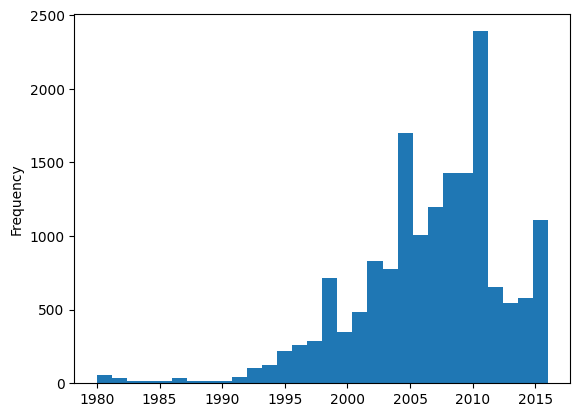

In [24]:
# Criar um histograma para ver quais são os anos que mais tem lançamento de jogos

df_for_hist = df[df['year_of_release'] != 0]
df_for_hist['year_of_release'].plot(kind='hist', bins=30)

Após análise do histograma, seria interessante usar dados a partir de 2013, pois temos dados até 2016.

In [25]:
# Filtrando o df principal para trabalhar somente com os dados que interessam (year_of_release > 2013)

df_filtered_for_analysis = df[df['year_of_release'] >= 2013]
df_filtered_for_analysis

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sale,media_score,best_region
16,Grand Theft Auto V,PS3,2013.0,Action,7.02,9.09,0.98,3.96,9.7,8.2,M,21.05,8.95,eu_sales
23,Grand Theft Auto V,X360,2013.0,Action,9.66,5.14,0.06,1.41,9.7,8.1,M,16.27,8.90,na_sales
31,Call of Duty: Black Ops 3,PS4,2015.0,Shooter,6.03,5.86,0.36,2.38,NaN,NaN,unknown,14.63,NaN,na_sales
33,Pokemon X/Pokemon Y,3DS,2013.0,Role-Playing,5.28,4.19,4.35,0.78,NaN,NaN,unknown,14.60,NaN,na_sales
42,Grand Theft Auto V,PS4,2014.0,Action,3.96,6.31,0.38,1.97,9.7,8.3,M,12.62,9.00,eu_sales
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16703,Strawberry Nauts,PSV,2016.0,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,unknown,0.01,NaN,jp_sales
16707,Aiyoku no Eustia,PSV,2014.0,Misc,0.00,0.00,0.01,0.00,NaN,NaN,unknown,0.01,NaN,jp_sales
16710,Samurai Warriors: Sanada Maru,PS3,2016.0,Action,0.00,0.00,0.01,0.00,NaN,NaN,unknown,0.01,NaN,jp_sales
16712,Haitaka no Psychedelica,PSV,2016.0,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,unknown,0.01,NaN,jp_sales


In [26]:
filtro_por_plataforma = df_filtered_for_analysis.groupby(by='platform').sum().reset_index()
top_10_platform_sale = filtro_por_plataforma[['platform','total_sale']].sort_values(by='total_sale', ascending=False).head(10)
top_10_platform_sale

,platform,total_sale
4,PS4,314.14
3,PS3,181.43
10,XOne,159.32
0,3DS,143.25
9,X360,136.80
8,WiiU,64.63
2,PC,39.43
6,PSV,32.99
7,Wii,13.66
5,PSP,3.50


<Figure size 2000x4000 with 0 Axes>

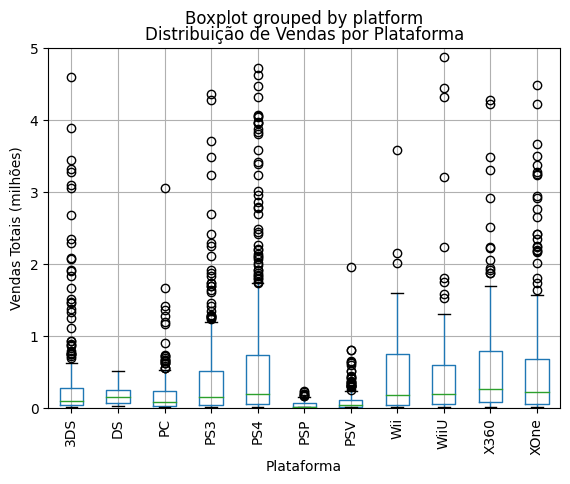

In [27]:
plt.figure(figsize=(20,40))
df_filtered_for_analysis.boxplot(column='total_sale', by='platform')
plt.title('Distribuição de Vendas por Plataforma')
plt.ylabel('Vendas Totais (milhões)')
plt.xlabel('Plataforma')
plt.xticks(rotation=90)
plt.ylim(0,5)
plt.show()

# Descrever o que vejo no diagrama de caixa

* As plataformas PS4, Wii e X360 possuem caixas maiores(interquartil mais largo)
* Muitos outliers, indicam que alguns jogos vendem MUITO mais

# Avaliando a plataforma PS4

In [28]:
# Filtrando o df para mostrar apenas as linhas da plataforma PS4

df_filtered_for_analysis_ps4 = df_filtered_for_analysis[df_filtered_for_analysis['platform'] == 'PS4']
df_filtered_for_analysis_ps4

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sale,media_score,best_region
31,Call of Duty: Black Ops 3,PS4,2015.0,Shooter,6.03,5.86,0.36,2.38,NaN,NaN,unknown,14.63,NaN,na_sales
42,Grand Theft Auto V,PS4,2014.0,Action,3.96,6.31,0.38,1.97,9.7,8.3,M,12.62,9.00,eu_sales
77,FIFA 16,PS4,2015.0,Sports,1.12,6.12,0.06,1.28,8.2,4.3,E,8.58,6.25,eu_sales
87,Star Wars Battlefront (2015),PS4,2015.0,Shooter,2.99,3.49,0.22,1.28,NaN,NaN,unknown,7.98,NaN,eu_sales
92,Call of Duty: Advanced Warfare,PS4,2014.0,Shooter,2.81,3.48,0.14,1.23,8.3,5.7,M,7.66,7.00,eu_sales
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16500,Root Letter,PS4,2016.0,Adventure,0.00,0.00,0.01,0.00,6.9,7.5,unknown,0.01,7.20,jp_sales
16503,Shin Hayarigami 2,PS4,2016.0,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,unknown,0.01,NaN,jp_sales
16526,Dungeons 2,PS4,2016.0,Role-Playing,0.01,0.00,0.00,0.00,6.1,7.9,T,0.01,7.00,na_sales
16530,Carmageddon: Max Damage,PS4,2016.0,Action,0.01,0.00,0.00,0.00,5.1,5.5,M,0.01,5.30,na_sales


In [29]:
# Cáclulo da correlação entre a média das avaliacoes e venda total

corr_score_sale1 = df_filtered_for_analysis_ps4['total_sale'].corr(df_filtered_for_analysis_ps4['user_score'])

corr_score_sale2 = df_filtered_for_analysis_ps4['total_sale'].corr(df_filtered_for_analysis_ps4['critic_score'])

print(corr_score_sale1,corr_score_sale2)

-0.031957110204556376 0.4065679020617812


<function matplotlib.pyplot.show(close=None, block=None)>

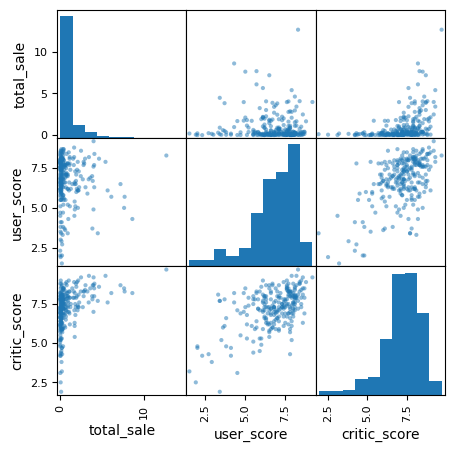

In [30]:
pd.plotting.scatter_matrix(df_filtered_for_analysis_ps4[['total_sale', 'user_score', 'critic_score']], figsize=(5,5))
plt.show

## Regiões que mais vendem

In [31]:
regioes = df_filtered_for_analysis['best_region'].unique()
regioes

array(['eu_sales', 'na_sales', 'jp_sales'], dtype=object)

In [32]:
for regiao in regioes:
    print(f"{regiao}: {len(df_filtered_for_analysis[df_filtered_for_analysis['best_region'] == regiao])}")

eu_sales: 691
na_sales: 766
jp_sales: 776


# Qual plataforma mais vende cada jogo - lançado no mínimo em 2 plataformas

In [33]:
# Criar um pivô: name x platform, valores = total_sale

pivot = df_filtered_for_analysis.pivot_table(
    index='name',             # LINHAS = nomes dos jogos
    columns='platform',       # COLUNAS = plataformas
    values = 'total_sale',    # VALORES = total de vendas
)
pivot = pivot.dropna(axis=0, thresh=2)# Excluindo as linhas que tenham somente os jogos que foram lançados em uma unica platarforma

In [34]:
# Encontrar para cada jogo, qual plataforma vendeu mais

best_platform = pivot.idxmax(axis=1)

In [35]:
# Encontrar o valor total para cada jogo

best_sales = pivot.max(axis=1)

In [36]:
# Criar um DataFrame com o resultado

resultado = pd.DataFrame({'best_platform': best_platform,
                         'best_total_sale': best_sales
                         })

In [37]:
top_10_games = resultado.sort_values(by='best_total_sale', ascending=False).head(10)
top_10_games

,best_platform,best_total_sale
name,,
Grand Theft Auto V,PS3,21.05
Call of Duty: Black Ops 3,PS4,14.63
Call of Duty: Ghosts,X360,10.24
Minecraft,X360,9.18
FIFA 16,PS4,8.58
Star Wars Battlefront (2015),PS4,7.98
Call of Duty: Advanced Warfare,PS4,7.66
FIFA 17,PS4,7.60
Super Smash Bros. for Wii U and 3DS,3DS,7.55


# Avaliando os generos

In [38]:
filtered_by_genre_sum = df_filtered_for_analysis.groupby(by='genre').sum().sort_values(by='total_sale', ascending=False)
filtered_by_genre_sum = filtered_by_genre_sum.drop(columns=['year_of_release','media_score', 'user_score', 'critic_score'])
filtered_by_genre_sum

,na_sales,eu_sales,jp_sales,other_sales,total_sale
genre,,,,,
Action,126.05,118.13,40.49,37.20,321.87
Shooter,109.74,87.86,6.61,28.77,232.98
Sports,65.27,60.52,5.41,19.45,150.65
Role-Playing,46.40,36.97,51.04,11.48,145.89
Misc,27.49,20.04,9.20,6.09,62.82
Platform,18.14,15.58,4.79,4.12,42.63
Racing,12.96,20.19,2.30,4.44,39.89
Fighting,15.55,8.55,7.65,3.56,35.31
Adventure,7.14,8.25,5.82,2.43,23.64


## Conclusões

1 - Action é o genero mais vendido na America do Norte e Europa

2 - Shooter e Sports completam o Top 3
    - Ambos possuem desempenho forte na América do Norte e Europa.

3 - Role-Playing tem forte presença no Japão
    - RPG é  altamente cultural no mercado japonês, mas perde força no ocidente.

4 - Puzzlem, Strategy e Simulation com menor desempenho global.


# Análise de perfil de usuário para cada região

In [39]:
platform_sale_geral = filtro_por_plataforma[['platform','na_sales','eu_sales','jp_sales','total_sale']].sort_values(by='total_sale', ascending=False)

In [40]:
filter_by_rating = df_filtered_for_analysis.groupby(by='rating').sum().drop(columns=['year_of_release','other_sales','critic_score','media_score','user_score']).sort_values(by='total_sale', ascending=False)

In [41]:
# Função para mostraro TOP 5 de cada região

def analise_por_regiao(regiao):
    plataforma = platform_sale_geral.sort_values(by=regiao, ascending=False).head(5)
    genero = filtered_by_genre_sum.sort_values(by=regiao, ascending=False).head(5)
    classificacao = filter_by_rating.sort_values(by=regiao, ascending=False).head(5)

    return plataforma['platform'], genero.index, classificacao.index

In [42]:
# Para América do Norte
top_plat_na, top_gen_na, top_rating_na = analise_por_regiao('na_sales')

# Para Europa
top_plat_eu, top_gen_eu, top_rating_eu = analise_por_regiao('eu_sales')

# Para Japão
top_plat_jp, top_gen_jp, top_rating_jp = analise_por_regiao('jp_sales')

## Análise por Plataforma

In [43]:
print("As plataformas mais vendidas são:")
print()
print(f"América do Norte: {list(top_plat_na)}")
print(f"Europa: {list(top_plat_eu)}")
print(f"Japão: {list(top_plat_jp)}")

As plataformas mais vendidas são:

América do Norte: ['PS4', 'XOne', 'X360', 'PS3', '3DS']
Europa: ['PS4', 'PS3', 'XOne', 'X360', '3DS']
Japão: ['3DS', 'PS3', 'PSV', 'PS4', 'WiiU']


### Conclusão

* A Plataforma PS4 está presente no TOP 5 de todas as regiões.
* Há uma certa semelhança entre América do Norte e Europa, alterando apenas a ordem. 

## Análise por Genero

In [44]:
print("Os generos mais vendidos são:")
print()
print(f"América do Norte: {list(top_gen_na)}")
print(f"Europa: {list(top_gen_eu)}")
print(f"Japão: {list(top_gen_jp)}")

Os generos mais vendidos são:

América do Norte: ['Action', 'Shooter', 'Sports', 'Role-Playing', 'Misc']
Europa: ['Action', 'Shooter', 'Sports', 'Role-Playing', 'Racing']
Japão: ['Role-Playing', 'Action', 'Misc', 'Fighting', 'Shooter']


### Conclusão

* Action e Shooter estão presentes no TOP 5 de todas as regioes
* Há uma certa semelhança entre América do Note e Europa

## Análise por Classificação

In [45]:
print("As classificações mais vendidas são:")
print()
print(f"América do Norte: {list(top_rating_na)}")
print(f"Europa: {list(top_rating_eu)}")
print(f"Japão: {list(top_rating_jp)}")


As classificações mais vendidas são:

América do Norte: ['M', 'unknown', 'E', 'E10+', 'T']
Europa: ['M', 'E', 'unknown', 'E10+', 'T']
Japão: ['unknown', 'T', 'E', 'M', 'E10+']


### Conclusão

* Há vários jogos sem classificação
* As classificações são as mesmas em todas as regiões, alterando apenas suas posições

# Teste de Hipótese

## Hipótese nula: 
#### As classificações médias dos usuários das plataformas Xbox One e PC são as mesmas

## Hipótese alternativa: 
#### As classificações médias dos usuários das plataformas Xbox One e PC são diferentes

In [46]:
# Seperando a classificaão de cada plataforma

classificacao_xone = df_filtered_for_analysis[df_filtered_for_analysis['platform'] == 'XOne']['user_score']
classificacao_xone = classificacao_xone.dropna()

classificacao_pc = df_filtered_for_analysis[df_filtered_for_analysis['platform'] == 'PC']['user_score']
classificacao_pc = classificacao_pc.dropna()

In [47]:
classificacao_xone.var(), classificacao_pc.var()

(1.9069968429360695, 3.035892752408882)

In [48]:
# Teste

alpha = 0.05

results = st.ttest_ind(classificacao_xone, classificacao_pc, equal_var=False) # Variancia diferente, equal_var=False
print('valor-p: ', results.pvalue)

if results.pvalue < alpha:
    print('Rejeitamos hipótese nula.')
else:
    print('Não podemos rejeitar a hipótese nula.')

valor-p:  0.14759594013430463
Não podemos rejeitar a hipótese nula.


### Conclusão

Existe evidência estatística forte de que os usuários avaliam jogos do XboxOne e de PC de maneira diferente, ou seja, as médias das notas são significamente diferentes. 

## Hipótese nula: 
#### As classificações médias de usuários para os gêneros Action (ação) e Sports (esportes) são iguais.

## Hipótese alternativa: 
#### As classificações médias de usuários para os gêneros Action (ação) e Sports (esportes) são diferentes.

In [49]:
classificacao_action = df_filtered_for_analysis[df_filtered_for_analysis['genre'] == 'Action']['user_score']
classificacao_action = classificacao_action.dropna()

classificacao_sports = df_filtered_for_analysis[df_filtered_for_analysis['genre'] == 'Sports']['user_score']
classificacao_sports = classificacao_sports.dropna()

In [50]:
classificacao_action.var(), classificacao_sports.var()

(1.7693609042482705, 3.180612814465409)

In [51]:
# Teste

alpha = 0.05

results1 = st.ttest_ind(classificacao_action, classificacao_sports, equal_var=False)  # Variancia diferente, equal_var=False
print('valor-p: ', results1.pvalue)

if results1.pvalue < alpha:
    print('Rejeitamos hipótese nula.')
else:
    print('Não podemos rejeitar a hipótese nula.')


valor-p:  1.4460039700704315e-20
Rejeitamos hipótese nula.


### Conclusão

Não existe diferença estatisticamnte significativa entre as notas de usuários para jogos de ação e esportes.

# Conclusão Geral

Com o objetivo de maximizar receita, temos:
* América do Norte e Europa
    - Dar foco maior nas plataformas XOna, PS4 e PS3
    - Priorizar os generos Action e Shooter
* Japão
    - Dar foco maior nas plataformas 3DS e PS3
    - Priorizar os generos Role-Playing e Action

As classificações médias dos usuários das plataformas Xbox One e PC são DIFERENTES.

As classificações médias dos usuários para os gêneros Action (ação) e Sports (esportes) são PARECIDAS.